c:\Users\26293\Desktop\WORK\emhass_git\emhass\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset loaded. Shape: (17524, 3)

==== Pre-model Feature Analysis ====


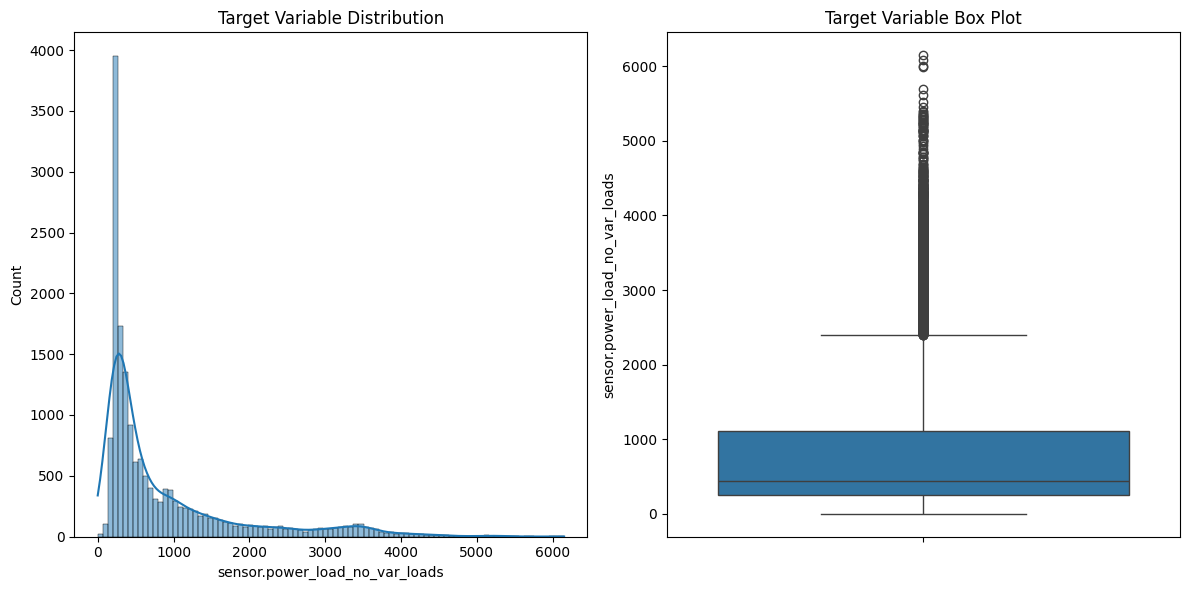

C:\Users\26293\AppData\Local\Temp\ipykernel_26732\4105814931.py:59: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_regular = df_final[var_model].asfreq('30T')


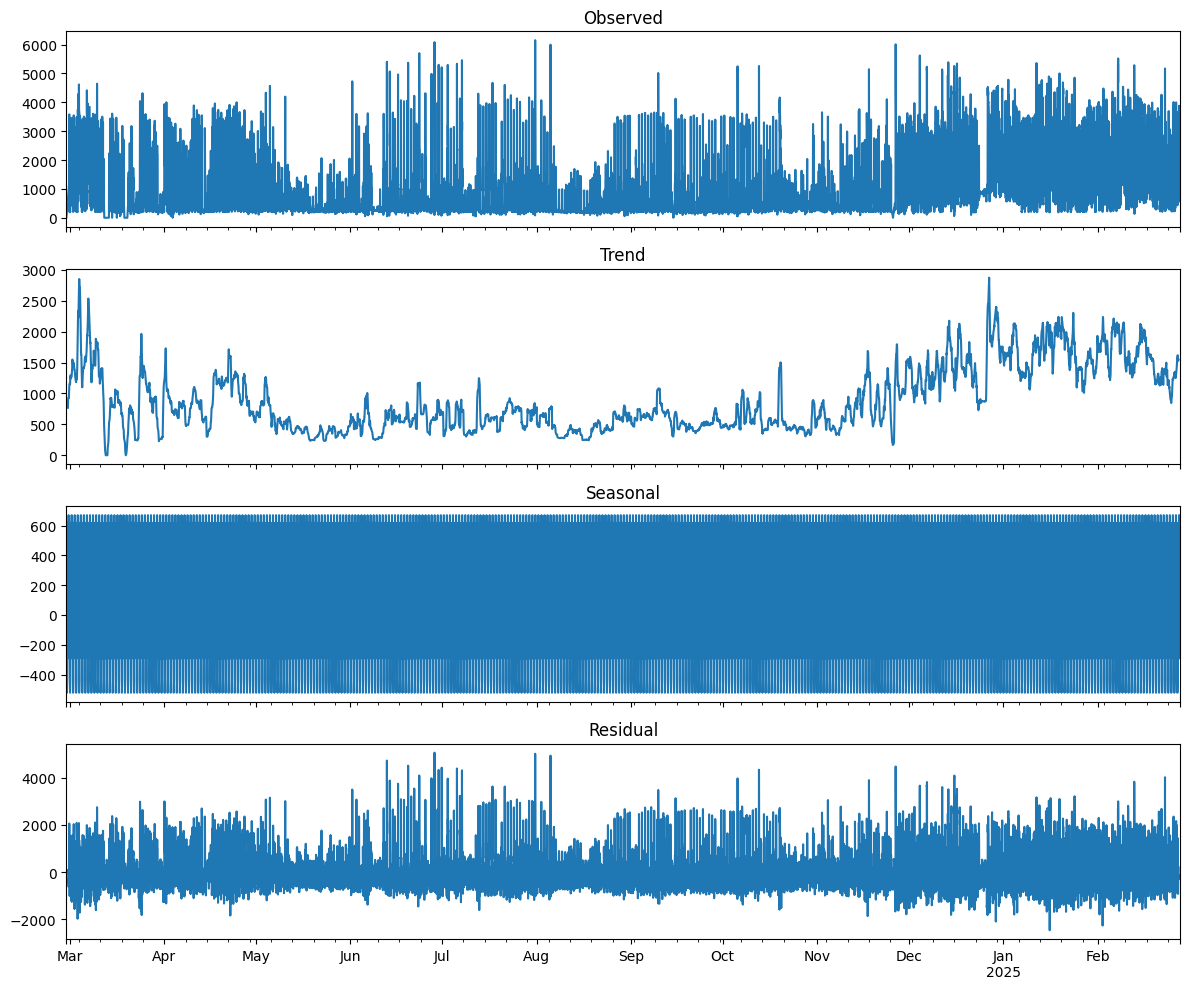

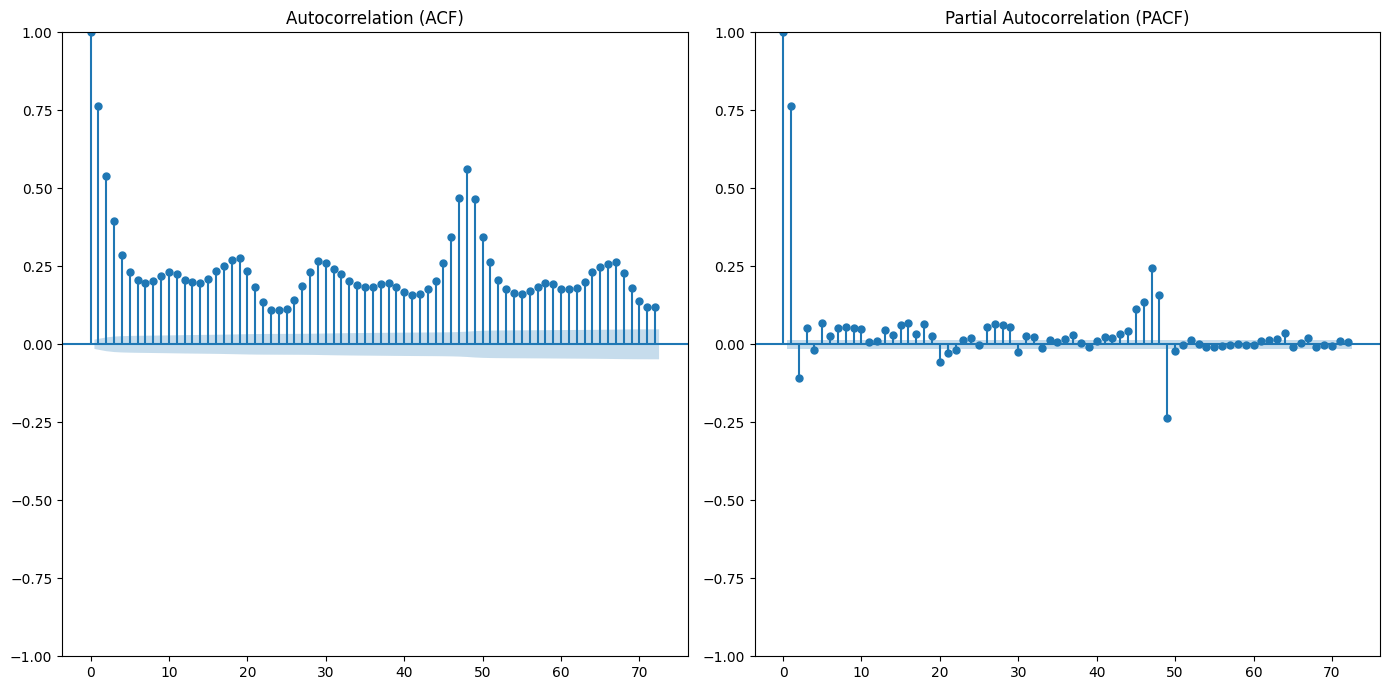

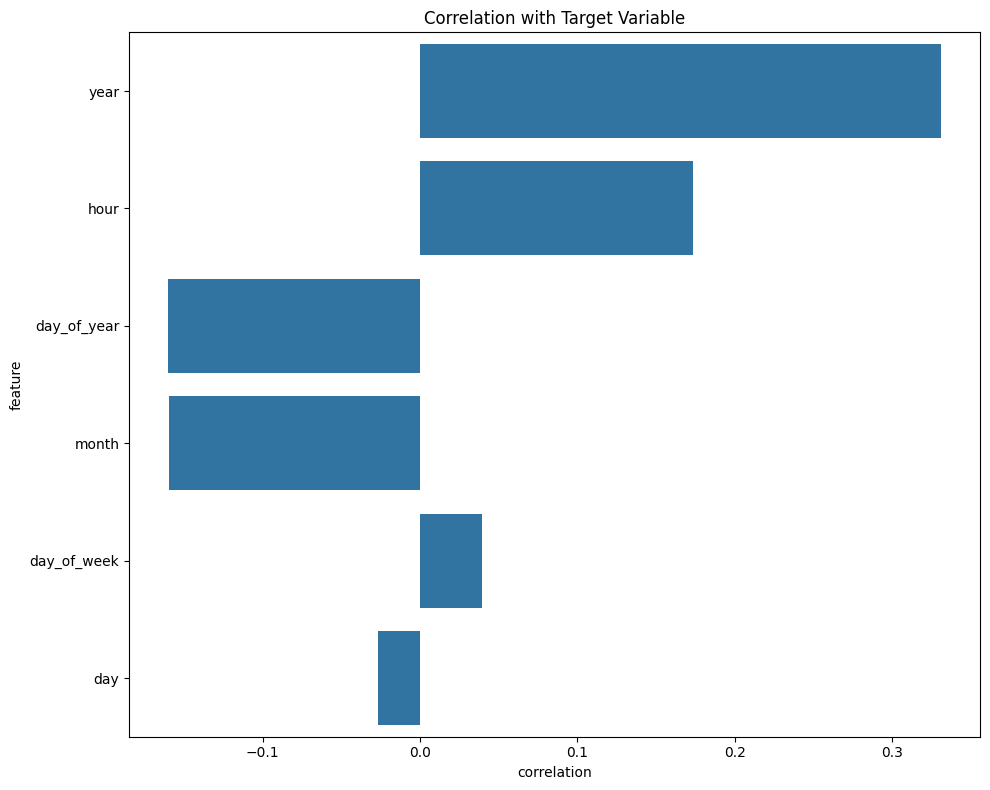

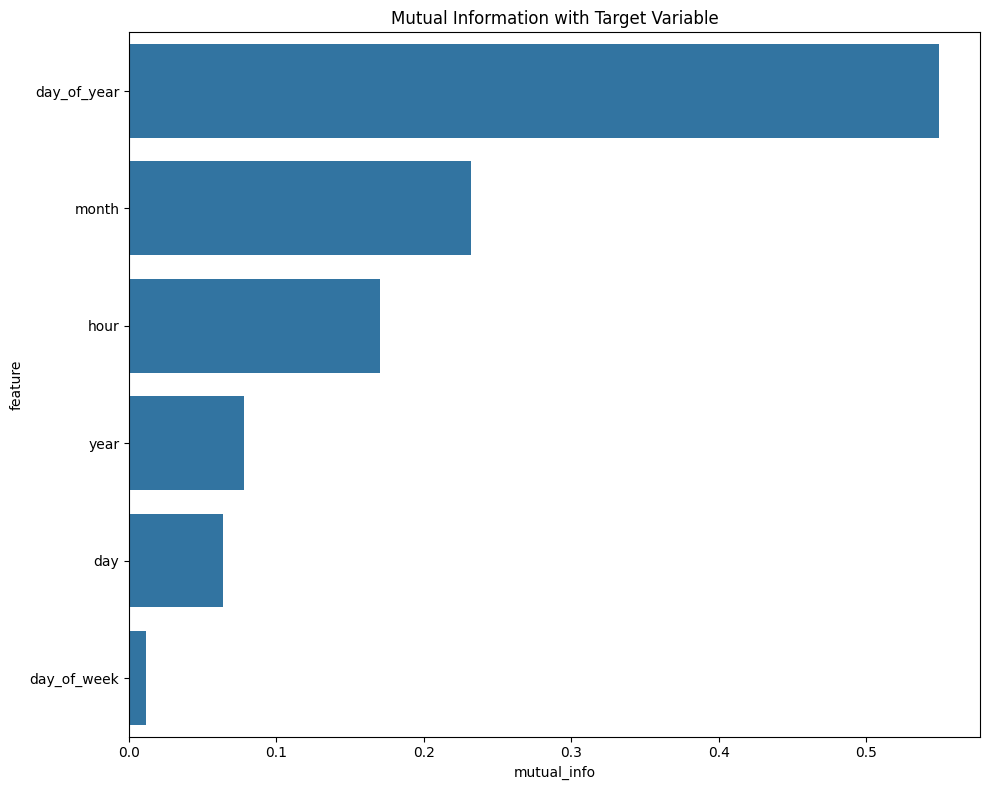


==== Daily and Weekly Patterns ====


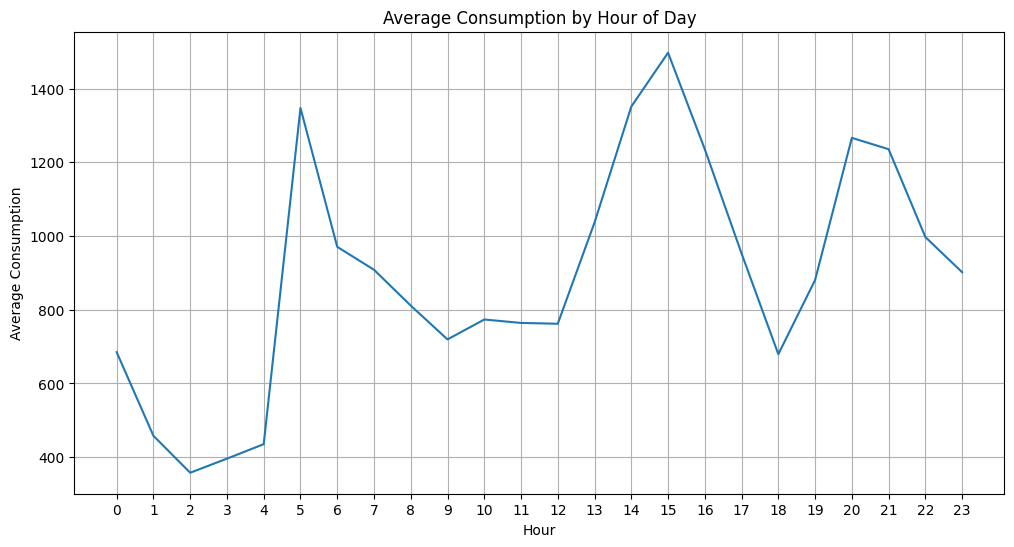

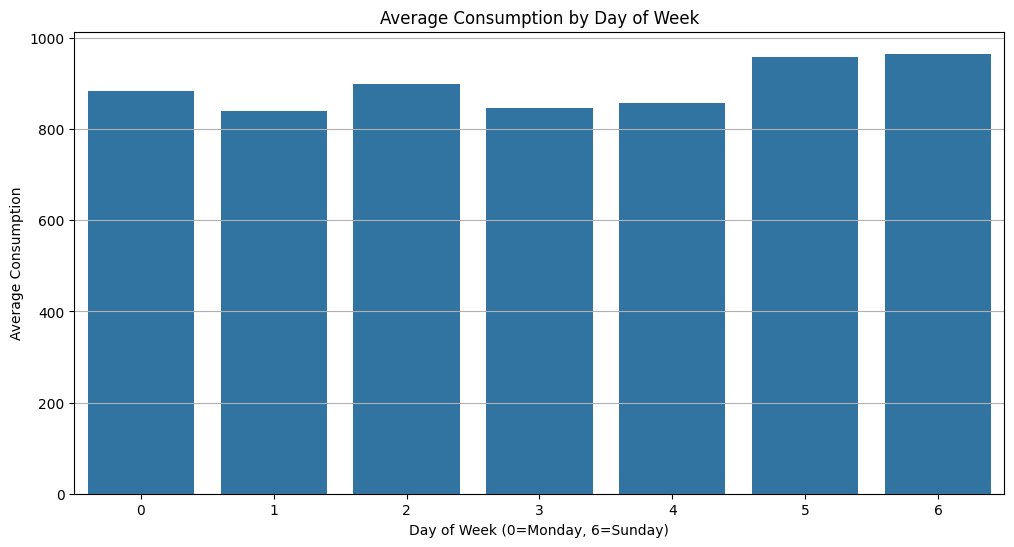

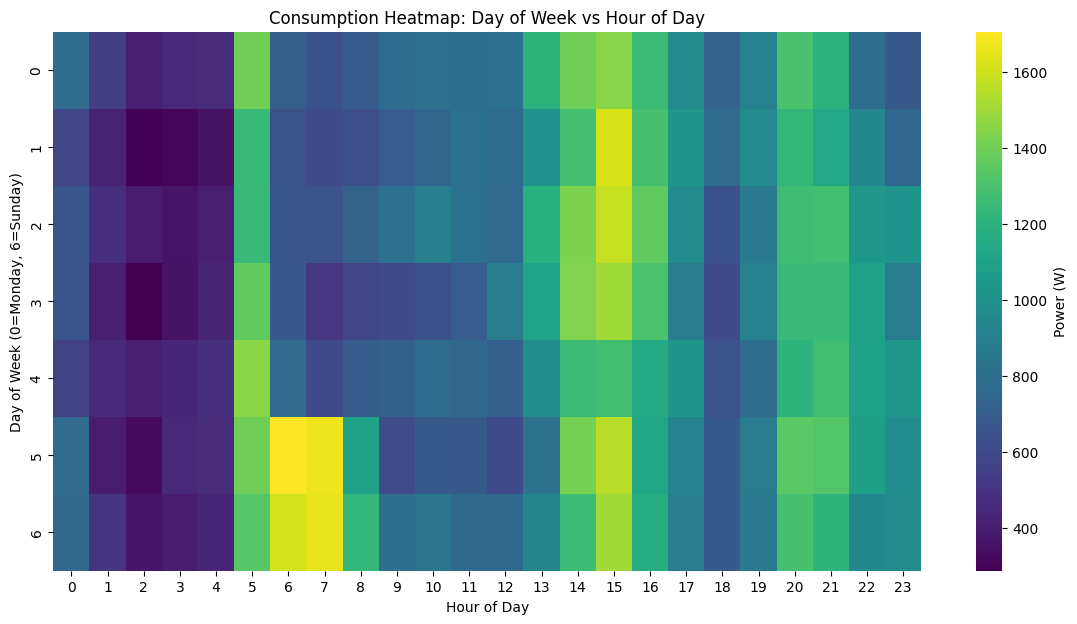

In [1]:
# Enhanced Feature Importance Analysis for Energy Forecasting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import pickle
import pathlib
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from xgboost import XGBRegressor
from emhass.machine_learning_forecaster import MLForecaster
from emhass import utils
# Reset pandas plotting backend to matplotlib
import pandas as pd
pd.options.plotting.backend = "matplotlib"

# Setup paths and logger
root = pathlib.Path(r"c:\Users\26293\Desktop\WORK\emhass_git\emhass")
emhass_conf = {
    "data_path": root / "data/",
    "root_path": root / "src/emhass/",
    "defaults_path": root / "src/emhass/data/config_defaults.json",
    "associations_path": root / "src/emhass/data/associations.csv",
}
logger, ch = utils.get_logger("notebook", emhass_conf, save_to_file=False)

# Load test data
with open(emhass_conf["data_path"] / "long_train_data.pkl", "rb") as inp:
    df_final, days_list, var_list, ha_config = pickle.load(inp)

# Configure model parameters
model_type = "long_train_data"
var_model = "sensor.power_load_no_var_loads"
num_lags = 48

print("Dataset loaded. Shape:", df_final.shape)

# Part 1: Pre-model Feature Analysis
print("\n==== Pre-model Feature Analysis ====")

# 1.1 Examine target variable distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_final[var_model], kde=True)
plt.title("Target Variable Distribution")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_final[var_model])
plt.title("Target Variable Box Plot")
plt.tight_layout()
plt.show()

# 1.2 Time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the data is at regular intervals
df_regular = df_final[var_model].asfreq('30T')
df_regular = df_regular.interpolate()

# Perform decomposition
decomposition = seasonal_decompose(df_regular, model='additive', period=48)  # 48 half-hours = 24 hours

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0])
axes[0].set_title("Observed")
decomposition.trend.plot(ax=axes[1])
axes[1].set_title("Trend")
decomposition.seasonal.plot(ax=axes[2])
axes[2].set_title("Seasonal")
decomposition.resid.plot(ax=axes[3])
axes[3].set_title("Residual")
plt.tight_layout()
plt.show()

# 1.3 Autocorrelation analysis
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plot_acf(df_final[var_model].dropna(), lags=72, ax=plt.gca())
plt.title("Autocorrelation (ACF)")

plt.subplot(1, 2, 2)
plot_pacf(df_final[var_model].dropna(), lags=72, ax=plt.gca())
plt.title("Partial Autocorrelation (PACF)")
plt.tight_layout()
plt.show()


# 1.4 Feature correlation with target
# Create datetime features
df_features = pd.DataFrame(index=df_final.index)
df_features = utils.add_date_features(df_features)
df_features[var_model] = df_final[var_model]

# Calculate correlations with target
correlations = {}
for col in df_features.columns:
    if col != var_model:
        corr, _ = pearsonr(df_features[col].fillna(0), df_features[var_model].fillna(0))
        correlations[col] = corr

corr_df = pd.DataFrame({'feature': list(correlations.keys()),
                       'correlation': list(correlations.values())})
corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='correlation', y='feature', data=corr_df)
plt.title('Correlation with Target Variable')
plt.tight_layout()
plt.show()

# 1.5 Mutual Information (non-linear relationships)
X = df_features.drop(var_model, axis=1)
y = df_features[var_model]

mi = mutual_info_regression(X.fillna(0), y.fillna(0))
mi_df = pd.DataFrame({'feature': X.columns, 'mutual_info': mi})
mi_df = mi_df.sort_values('mutual_info', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='mutual_info', y='feature', data=mi_df)
plt.title('Mutual Information with Target Variable')
plt.tight_layout()
plt.show()

# Part 2: Daily and Weekly Patterns
print("\n==== Daily and Weekly Patterns ====")

# 2.1 Average consumption by hour of day
df_features['hour'] = df_features.index.hour
hourly_avg = df_features.groupby('hour')[var_model].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values)
plt.title('Average Consumption by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Consumption')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

# 2.2 Average consumption by day of week
df_features['day_of_week'] = df_features.index.dayofweek
daily_avg = df_features.groupby('day_of_week')[var_model].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=daily_avg.index, y=daily_avg.values)
plt.title('Average Consumption by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Consumption')
plt.grid(True, axis='y')
plt.show()

# 2.3 Heatmap: Hour of day vs Day of week
pivot = df_features.pivot_table(
    index='day_of_week', columns='hour', values=var_model, aggfunc='mean')

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, cmap='viridis', annot=False, fmt='.0f', cbar_kws={'label': 'Power (W)'})
plt.title('Consumption Heatmap: Day of Week vs Hour of Day')
plt.ylabel('Day of Week (0=Monday, 6=Sunday)')
plt.xlabel('Hour of Day')
plt.show()

In [11]:
import plotly.graph_objs as go
import plotly.subplots as sp

fig = sp.make_subplots(
    rows=4, cols=1, shared_xaxes=True,
    subplot_titles=["Observed", "Trend", "Seasonal", "Residual"]
)
fig.add_trace(go.Scatter(x=decomposition.observed.index, y=decomposition.observed, name="Observed"), row=1, col=1)
fig.add_trace(go.Scatter(x=decomposition.trend.index, y=decomposition.trend, name="Trend"), row=2, col=1)
fig.add_trace(go.Scatter(x=decomposition.seasonal.index, y=decomposition.seasonal, name="Seasonal"), row=3, col=1)
fig.add_trace(go.Scatter(x=decomposition.resid.index, y=decomposition.resid, name="Residual"), row=4, col=1)

# Add slider and zoom buttons
fig.update_layout(
    height=900,
    title_text="Time Series Decomposition (Interactive with Slider)",
    xaxis=dict(
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1d", step="day", stepmode="backward"),
                dict(count=7, label="1w", step="day", stepmode="backward"),
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(step="all")
            ])
        )
    )
)
fig.show()

In [13]:
import plotly.graph_objs as go

# Plot ACF
fig_acf = go.Figure()
fig_acf.add_trace(go.Bar(y=acf_vals, name="ACF"))
fig_acf.update_layout(title_text="Autocorrelation (ACF)", xaxis_title="Lag", yaxis_title="ACF")
fig_acf.show()

# Plot PACF
fig_pacf = go.Figure()
fig_pacf.add_trace(go.Bar(y=pacf_vals, name="PACF"))
fig_pacf.update_layout(title_text="Partial Autocorrelation (PACF)", xaxis_title="Lag", yaxis_title="PACF")

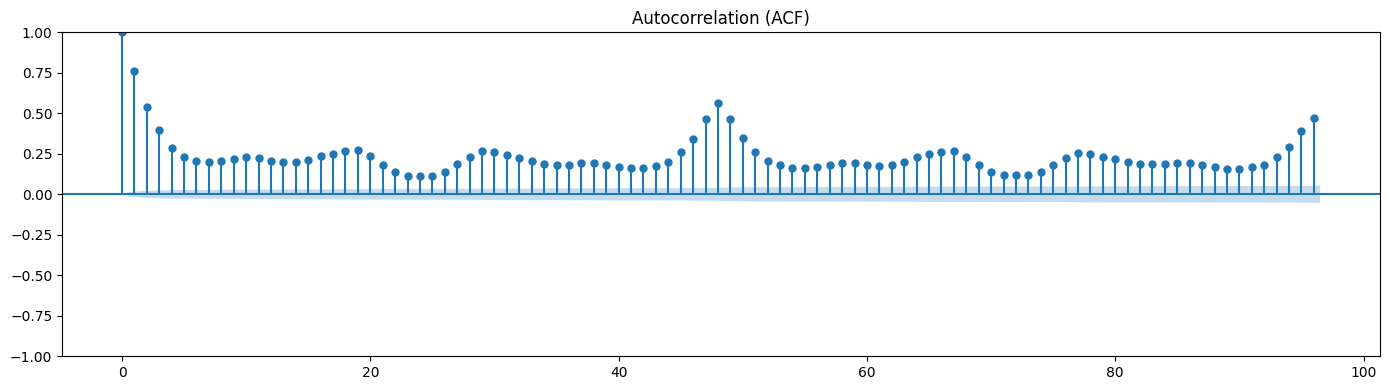

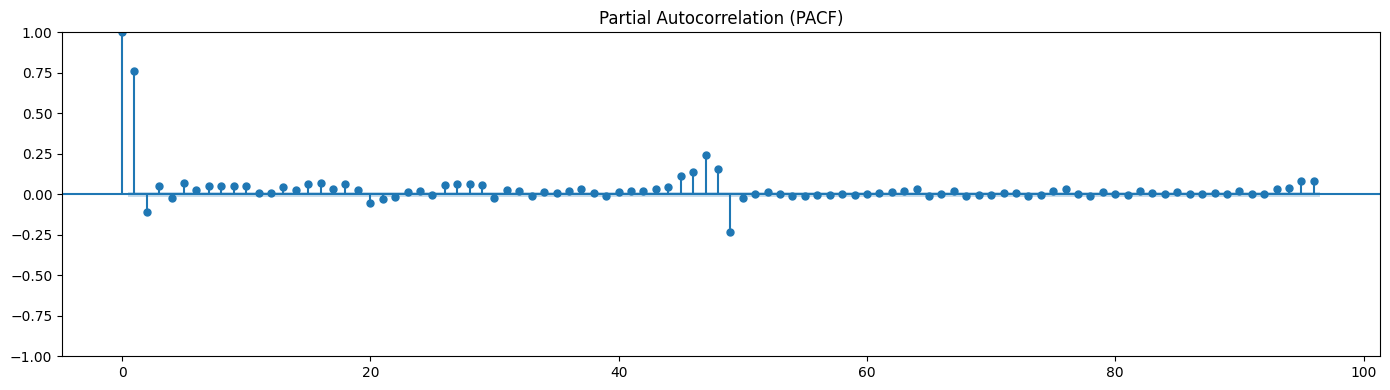

In [14]:
# 1.3 Autocorrelation analysis

plt.figure(figsize=(14, 4))
plot_acf(df_final[var_model].dropna(), lags=96, ax=plt.gca())
plt.title("Autocorrelation (ACF)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plot_pacf(df_final[var_model].dropna(), lags=96, ax=plt.gca())
plt.title("Partial Autocorrelation (PACF)")
plt.tight_layout()
plt.show()

2025-07-30 07:14:05,242 - notebook - INFO - Performing a forecast model fit for long_train_data
2025-07-30 07:14:05,250 - notebook - INFO - Training a LightGBM model
2025-07-30 07:14:05,395 - notebook - INFO - Elapsed time for model fit: 0.14328289031982422



==== Model-Based Feature Importance ====


2025-07-30 07:14:05,467 - notebook - INFO - Prediction R2 score of fitted model on test data: 0.7449937251889043
2025-07-30 07:14:05,471 - notebook - INFO - Model Evaluation Metrics:
2025-07-30 07:14:05,472 - notebook - INFO - R² Score: 0.7450
2025-07-30 07:14:05,473 - notebook - INFO - RMSE: 550.4279
2025-07-30 07:14:05,473 - notebook - INFO - MAE: 437.5288
2025-07-30 07:14:05,474 - notebook - INFO - MAPE: 56.36%


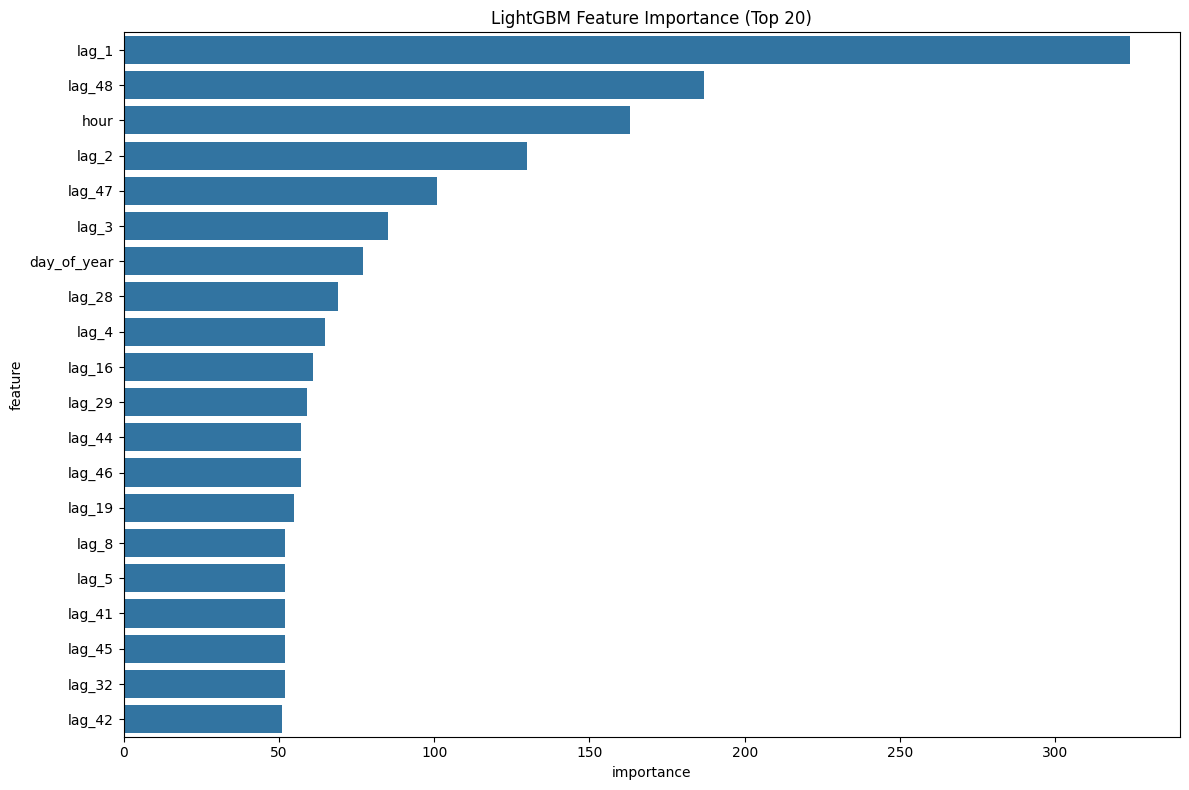

C:\Users\26293\AppData\Local\Temp\ipykernel_26732\2931328135.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'lag_{lag}'] = df[var_model].shift(lag)
C:\Users\26293\AppData\Local\Temp\ipykernel_26732\2931328135.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'lag_{lag}'] = df[var_model].shift(lag)
C:\Users\26293\AppData\Local\Temp\ipykernel_26732\2931328135.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

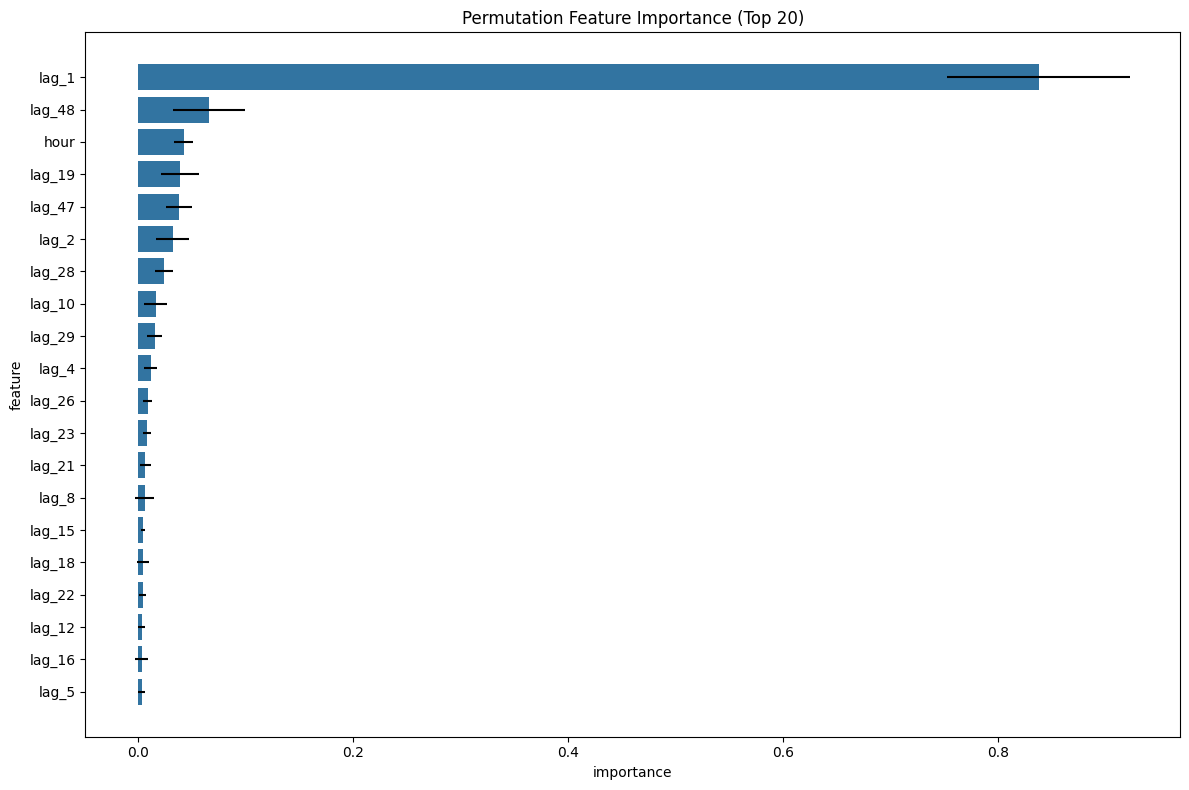


==== Lag Features Analysis ====


C:\Users\26293\AppData\Local\Temp\ipykernel_26732\2931328135.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_importance['lag_number'] = lag_importance['feature'].str.extract(r'lag_(\d+)').astype(int)


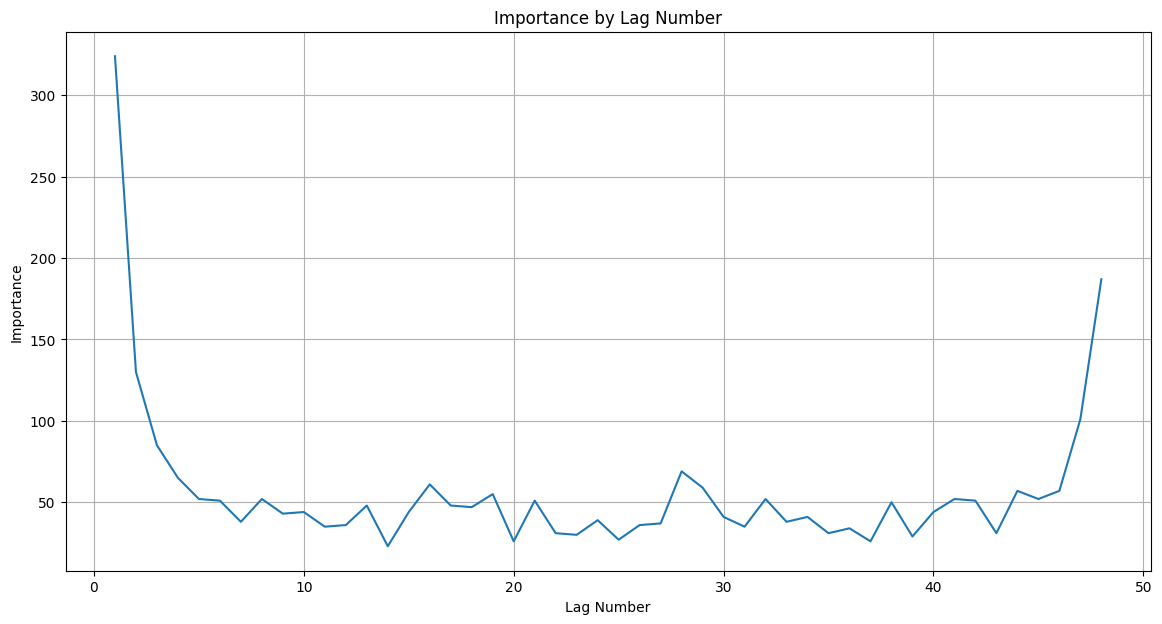

C:\Users\26293\AppData\Local\Temp\ipykernel_26732\2931328135.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_importance = lag_importance.groupby('period')['importance'].sum().reset_index()


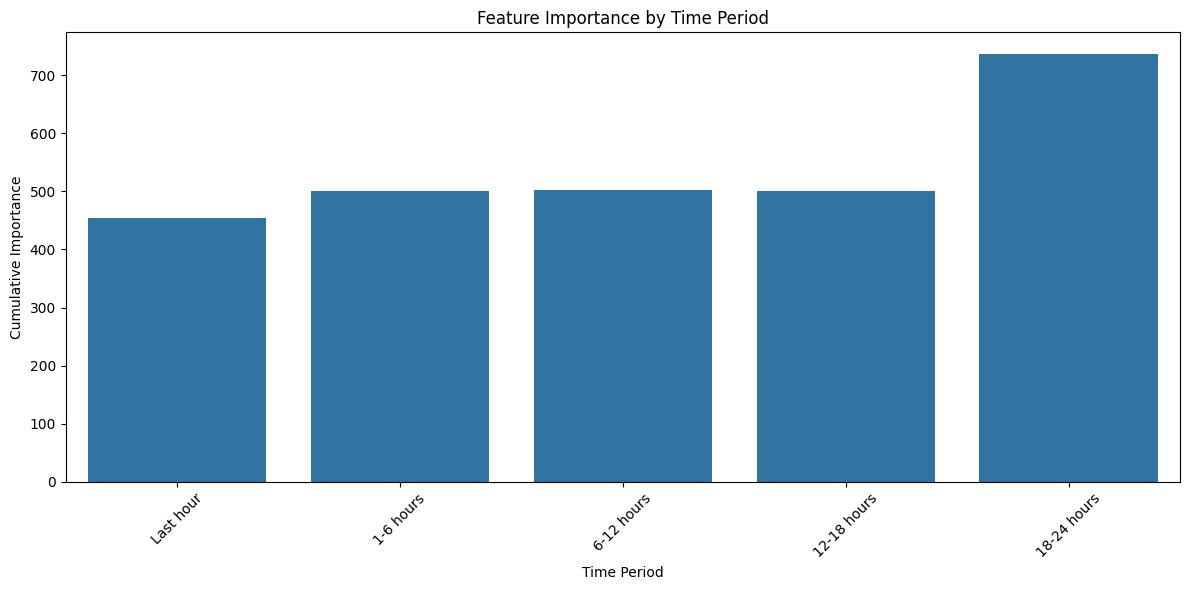


==== Insights and Recommendations ====
Top 10 most important features:
        feature  importance
0         lag_1         324
47       lag_48         187
53         hour         163
1         lag_2         130
46       lag_47         101
2         lag_3          85
51  day_of_year          77
27       lag_28          69
3         lag_4          65
15       lag_16          61

Most important time periods for lag features:
        period  importance
4  18-24 hours         737
2   6-12 hours         503
1    1-6 hours         501
3  12-18 hours         500
0    Last hour         454

Most important time features:
        feature  importance
53         hour         163
51  day_of_year          77
50  day_of_week          41
52          day          18
49        month           5

Recommendations:
1. Focus on the most important lags identified
2. Consider adding more features around the most important time periods
3. External data sources to consider:
   - Weather data (temperature, humid

In [8]:
# Part 3: Model-Based Feature Importance
print("\n==== Model-Based Feature Importance ====")

# 3.1 Fit LightGBM model and extract importance
sklearn_model = "LightGBM"
mlf_lgb = MLForecaster(df_final, model_type, var_model, sklearn_model, num_lags, emhass_conf, logger)
df_pred_lgb, _ = mlf_lgb.fit()

# Get the feature names actually used by the regressor
feature_names = mlf_lgb.forecaster.regressor.feature_name_

# Now create the DataFrame using these names
feature_importance_lgb = pd.DataFrame({
    'feature': feature_names,
    'importance': mlf_lgb.forecaster.regressor.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_lgb.head(20))
plt.title('LightGBM Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

# 3.2 Permutation importance (more reliable than built-in feature importance)
from sklearn.inspection import permutation_importance

def add_lags(df, var_model, num_lags):
    for lag in range(1, num_lags + 1):
        df[f'lag_{lag}'] = df[var_model].shift(lag)
    return df

# Apply to your test set (make sure to align with your training pipeline)
mlf_lgb.data_test = add_lags(mlf_lgb.data_test, mlf_lgb.var_model, num_lags)
mlf_lgb.data_test = mlf_lgb.data_test.dropna()
X_test = mlf_lgb.data_test[feature_names]
y_test = mlf_lgb.data_test[mlf_lgb.var_model]

# Calculate permutation importance
perm_importance = permutation_importance(
    mlf_lgb.forecaster.regressor, X_test.values, y_test.values, 
    n_repeats=10, random_state=42
)

# Create DataFrame with results
perm_imp_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Plot permutation importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=perm_imp_df.head(20))
plt.title('Permutation Feature Importance (Top 20)')
plt.errorbar(
    x=perm_imp_df.head(20)['importance'], 
    y=range(20), 
    xerr=perm_imp_df.head(20)['std'], 
    fmt='none', c='black'
)
plt.tight_layout()
plt.show()

# Part 4: Analysis of Lag Features Importance
print("\n==== Lag Features Analysis ====")

# 4.1 Filter lag features and their importance
lag_features = [col for col in feature_importance_lgb['feature'] if 'lag' in col.lower()]
lag_importance = feature_importance_lgb[feature_importance_lgb['feature'].isin(lag_features)]

# Sort by lag number for better visualization
lag_importance['lag_number'] = lag_importance['feature'].str.extract(r'lag_(\d+)').astype(int)
lag_importance = lag_importance.sort_values('lag_number')

plt.figure(figsize=(14, 7))
sns.lineplot(x='lag_number', y='importance', data=lag_importance)
plt.title('Importance by Lag Number')
plt.xlabel('Lag Number')
plt.ylabel('Importance')
plt.grid(True)
plt.show()

# 4.2 Group lag features by time periods
def lag_to_hours(lag_number, freq_minutes=30):
    return (lag_number * freq_minutes) / 60

lag_importance['hours_ago'] = lag_importance['lag_number'].apply(lag_to_hours)
lag_importance['period'] = pd.cut(
    lag_importance['hours_ago'], 
    bins=[0, 1, 6, 12, 18, 24], 
    labels=['Last hour', '1-6 hours', '6-12 hours', '12-18 hours', '18-24 hours']
)

period_importance = lag_importance.groupby('period')['importance'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='period', y='importance', data=period_importance)
plt.title('Feature Importance by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Cumulative Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Part 5: Insights and Recommendations
print("\n==== Insights and Recommendations ====")
print("Top 10 most important features:")
print(feature_importance_lgb.head(10))

print("\nMost important time periods for lag features:")
print(period_importance.sort_values('importance', ascending=False))

print("\nMost important time features:")
time_features = [col for col in feature_importance_lgb['feature'] if col in df_features.columns]
print(feature_importance_lgb[feature_importance_lgb['feature'].isin(time_features)].head(5))

# Recommendations based on findings
print("\nRecommendations:")
print("1. Focus on the most important lags identified")
print("2. Consider adding more features around the most important time periods")
print("3. External data sources to consider:")
print("   - Weather data (temperature, humidity)")
print("   - Calendar features (holidays, events)")
print("   - Additional household activity indicators")